# 03 — Modeling: benchmark, selection & calibration

**Goal:** train the outcome classifier *honestly* and pick the best model on evidence.

Principles (quant-flavored):
1. **No look-ahead bias** — train on the past (`< 2022`), test on the future (`>= 2022`).
2. **Always benchmark** — compare against naive base rates, Elo-only, and gradient boosting.
3. **Score probabilities, not labels** — log loss, multiclass Brier, and **RPS** (the
   ordinal football-forecasting score, cousin of the CRPS used in finance/meteorology).
4. **Parsimony** — when models tie, the simpler, interpretable one wins.

Logic lives in [`src/models/train.py`](../src/models/train.py).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / "reports" / "figures"

from src.models.train import (  # noqa: E402
    load_features, temporal_split, benchmark, build_model, FEATURES, CLASSES,
)

df = load_features()
train_df, test_df = temporal_split(df)
print(f"Train (<2022): {len(train_df):,}   Test (>=2022): {len(test_df):,}")

Train (<2022): 18,703   Test (>=2022): 4,568


## 1. Benchmark: which model is actually best?

Every model is trained only on pre-2022 matches and scored on 2022+ (which includes the
2022 World Cup). Lower is better for log loss / Brier / RPS.

model,accuracy,log_loss,brier,rps
Baseline (base rates),0.478,1.0503,0.6334,0.2283
Elo-only logistic,0.596,0.8794,0.5174,0.1729
GBDT (all features),0.598,0.8771,0.5156,0.1719
Logistic (all features) *selected*,0.599,0.8765,0.5151,0.1718


C:\Users\MatíasGaedechensMeye\AppData\Local\Temp\ipykernel_34352\2997816478.py:15: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\MatíasGaedechensMeye\AppData\Local\Temp\ipykernel_34352\2997816478.py:16: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(FIG_DIR / "07_model_benchmark.png", bbox_inches="tight")
C:\Dev\Worldcup\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


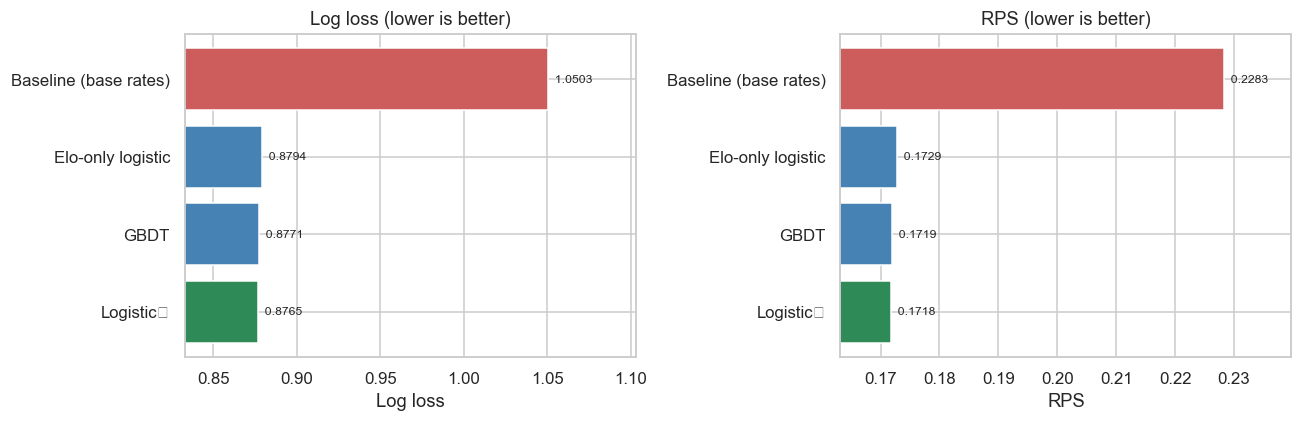

In [2]:
results = benchmark(df)
display(results.style.format({"accuracy": "{:.3f}", "log_loss": "{:.4f}",
                              "brier": "{:.4f}", "rps": "{:.4f}"}).hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
short = results["model"].str.replace(" (all features)", "", regex=False).str.replace(" *selected*", "\u2605", regex=False)
for ax, metric, title in zip(axes, ["log_loss", "rps"], ["Log loss", "RPS"]):
    colors = ["indianred"] + ["steelblue"] * (len(results) - 2) + ["seagreen"]
    ax.barh(short, results[metric], color=colors)
    ax.invert_yaxis()
    ax.set(title=f"{title} (lower is better)", xlabel=title)
    ax.set_xlim(left=results[metric].min() * 0.95)
    for i, v in enumerate(results[metric]):
        ax.text(v, i, f"  {v:.4f}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_model_benchmark.png", bbox_inches="tight")
plt.show()

**Reading it:** the gradient-boosting model does *not* beat a plain logistic regression,
and Elo alone is already most of the signal. Football is low-signal: extra complexity buys
almost nothing. So we select the **Logistic Regression** — simplest, best-scoring, and
interpretable. Choosing the simple model on evidence is a feature, not a weakness.

## 2. Is the model calibrated? (reliability diagram)

Accuracy is not enough — for a Monte Carlo simulation we need the *probabilities* to be
honest. A reliability diagram bins predictions and checks: when the model says "home wins
with prob p", does the home team actually win ~p of the time? This is the same idea as
back-testing a VaR model in finance.

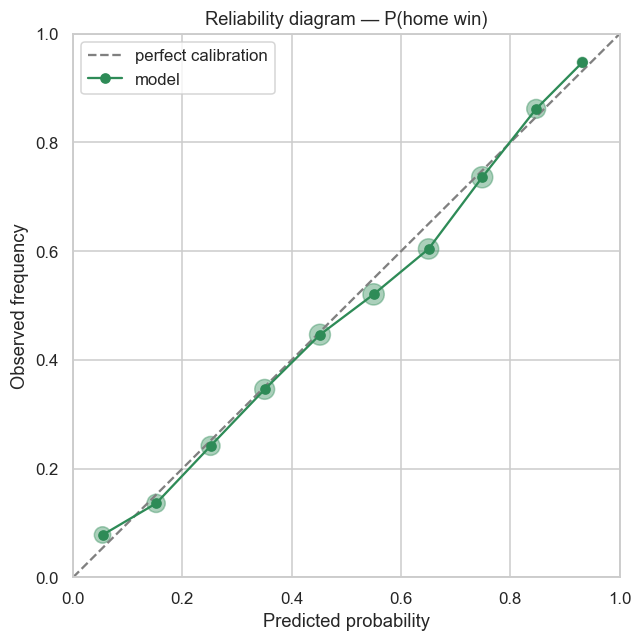

In [3]:
model = build_model().fit(train_df[FEATURES], train_df["target_idx"])
p_home = model.predict_proba(test_df[FEATURES])[:, CLASSES.index("H")]
y_home = (test_df["target_idx"].to_numpy() == CLASSES.index("H")).astype(int)

# Bin by predicted probability into deciles and compare to observed frequency.
bins = np.linspace(0, 1, 11)
idx = np.digitize(p_home, bins) - 1
rows = []
for b in range(10):
    m = idx == b
    if m.sum() > 0:
        rows.append({"pred": p_home[m].mean(), "obs": y_home[m].mean(), "n": int(m.sum())})
rel = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
ax.plot(rel["pred"], rel["obs"], "o-", color="seagreen", label="model")
ax.scatter(rel["pred"], rel["obs"], s=rel["n"] / 3, color="seagreen", alpha=0.4)
ax.set(title="Reliability diagram — P(home win)", xlabel="Predicted probability",
       ylabel="Observed frequency", xlim=(0, 1), ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08_calibration.png", bbox_inches="tight")
plt.show()

Points near the diagonal = well-calibrated probabilities. Logistic regression is
naturally well-calibrated, which is exactly what the simulation needs.

## 3. What did the model learn? (interpretability)

Because features are standardized, the logistic coefficients are directly comparable: a
larger magnitude = a stronger effect on that outcome's odds.

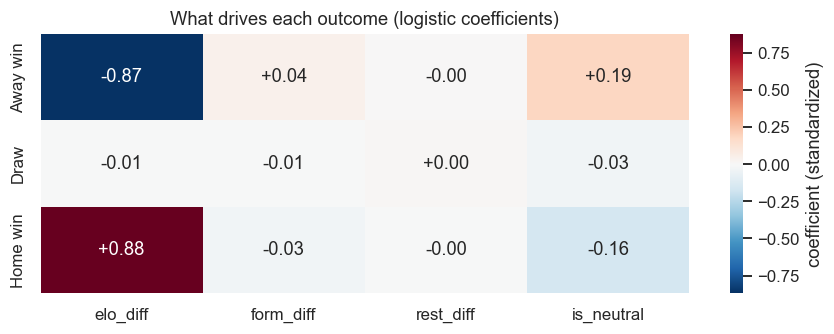

Sanity: a higher elo_diff should push toward Home win (+) and away from Away win (-).


In [4]:
coef = pd.DataFrame(model.named_steps["clf"].coef_, columns=FEATURES, index=CLASSES)
coef.index = ["Away win", "Draw", "Home win"]

fig, ax = plt.subplots(figsize=(8, 3.2))
sns.heatmap(coef, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "coefficient (standardized)"})
ax.set(title="What drives each outcome (logistic coefficients)")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_coefficients.png", bbox_inches="tight")
plt.show()

print("Sanity: a higher elo_diff should push toward Home win (+) and away from Away win (-).")

## Conclusions

- **Selected model:** standardized **multinomial Logistic Regression** on `elo_diff`,
  `form_diff`, `rest_diff`, `is_neutral`. It wins every proper score and is interpretable.
- **`elo_diff` dominates** — strength difference is by far the biggest driver, exactly as
  football intuition expects.
- **Probabilities are well-calibrated**, so they can be trusted by the Monte Carlo.
- The final model is refit on *all* data (`fit_final_model`) and saved to
  `models/wc_model.joblib` for the simulation.

➡️ **Next (Day 3):** `src/simulation/` — play the 48-team tournament 10,000 times with
these probabilities to estimate each nation's title odds.